# Weighted soft voting

/var/folders/vn/xptkmbp94g59_0vxqhb4_6lc0000gn/T/ipykernel_4265/1593278482.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  soft_preds = df_ws.groupby(group_col, group_keys=False).apply(soft_hat).reset_index(name='final_pred_label')


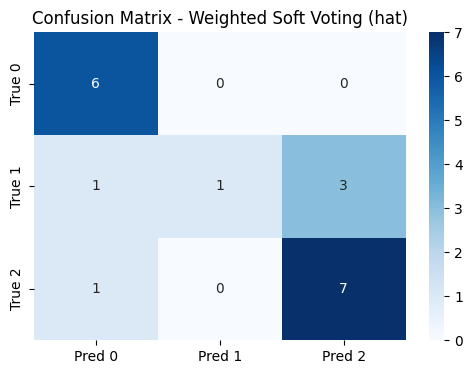

,Accuracy,F1-Score,Precision,Recall
Voting Strategy,,,,
Weighted Soft Voting (hat),73.68,68.59,79.47,73.68


In [4]:
import pandas as pd
import numpy as np
import re
import ast
import os
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

test = pd.read_csv('/Volumes/Extreme SSD/progetto_tesi/improving_dementia_detection_model/explainability-dementia-alfio/5_seed_ovr/results/train_20250720_163655/test_inferences.csv')

def convert_to_array(x):
        x = re.sub(r'(?<=\d)\s+(?=\d)', ',', x)
        x = '[' + x + ']'
        array = np.array(ast.literal_eval(x))
        return array 

test['softmax_values'] = test['softmax_values'].apply(lambda x: convert_to_array(x))
test['softmax_values'] = test['softmax_values'].apply(lambda x: x.squeeze())

def all_voting_strategies(df, group_col, pred_col, true_col, softmax_col):

    results_summary = []
    confusion_matrices = {}
    
    def get_metrics(y_true, y_pred):
        return {
            "Accuracy": round(accuracy_score(y_true, y_pred) * 100, 2),
            "F1-Score": round(f1_score(y_true, y_pred, average='weighted') * 100, 2),
            "Precision": round(precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
            "Recall": round(recall_score(y_true, y_pred, average='weighted') * 100, 2)
        }

    def plot_conf_matrix(y_true, y_pred, title):
        labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        df_cm = pd.DataFrame(cm, index=[f'True {l}' for l in labels],
                                  columns=[f'Pred {l}' for l in labels])
        plt.figure(figsize=(6,4))
        sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
        plt.title(title)
        plt.show()
        return df_cm

    # 1. Majority Voting
    majority_voting = df.groupby(group_col)[pred_col].agg(lambda x: x.mode()[0]).reset_index()
    true_labels = df.groupby(group_col)[true_col].first().reset_index()
    results = pd.merge(majority_voting, true_labels, on=group_col)
    y_true, y_pred = results[true_col], results[pred_col]

    # 3. Weighted Soft Voting
    df_ws = df.copy()
    df_ws['weight'] = df_ws[softmax_col].apply(np.max)
    def soft_hat(group):
        probs = np.stack(group[softmax_col].values)
        weights = group['weight'].values.reshape(-1, 1)
        weighted_probs = (probs * weights).sum(axis=0)
        return np.argmax(weighted_probs)
    soft_preds = df_ws.groupby(group_col, group_keys=False).apply(soft_hat).reset_index(name='final_pred_label')
    results = pd.merge(soft_preds, true_labels, on=group_col)
    y_true, y_pred = results[true_col], results['final_pred_label']
    confusion_matrices["Weighted Soft Voting (hat)"] = plot_conf_matrix(y_true, y_pred, "Confusion Matrix - Weighted Soft Voting (hat)")
    results_summary.append(("Weighted Soft Voting (hat)", get_metrics(y_true, y_pred)))

    # Build summary DataFrame
    summary_df = pd.DataFrame({name: metrics for name, metrics in results_summary}).T
    summary_df.index.name = 'Voting Strategy'

    return summary_df, confusion_matrices

test_summary, test_confusion_matrices = all_voting_strategies(test, 'original_rec', 'pred_label', 'true_label', 'softmax_values')
display(test_summary)


/var/folders/vn/xptkmbp94g59_0vxqhb4_6lc0000gn/T/ipykernel_4356/2352588279.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  soft_preds = df_ws.groupby(group_col, group_keys=False).apply(soft_hat).reset_index(name='final_pred_label')


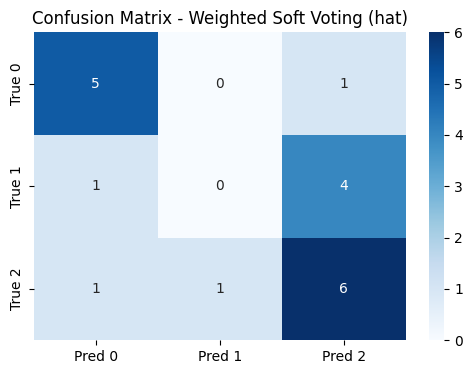

/var/folders/vn/xptkmbp94g59_0vxqhb4_6lc0000gn/T/ipykernel_4356/2352588279.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  soft_preds = df_ws.groupby(group_col, group_keys=False).apply(soft_hat).reset_index(name='final_pred_label')


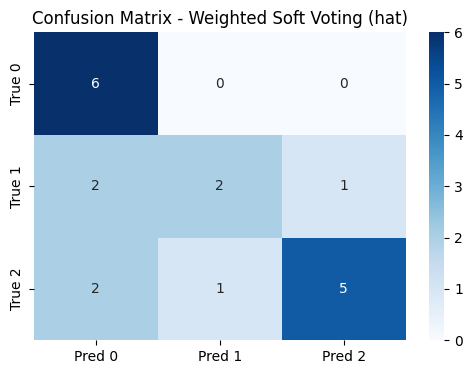

/var/folders/vn/xptkmbp94g59_0vxqhb4_6lc0000gn/T/ipykernel_4356/2352588279.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  soft_preds = df_ws.groupby(group_col, group_keys=False).apply(soft_hat).reset_index(name='final_pred_label')


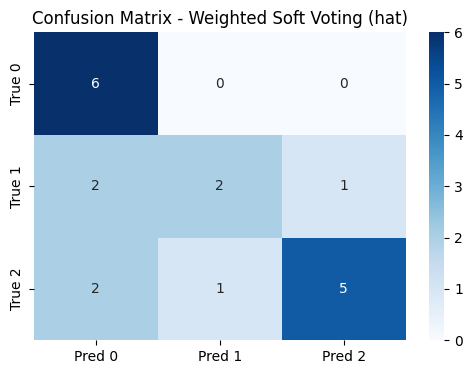

/var/folders/vn/xptkmbp94g59_0vxqhb4_6lc0000gn/T/ipykernel_4356/2352588279.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  soft_preds = df_ws.groupby(group_col, group_keys=False).apply(soft_hat).reset_index(name='final_pred_label')


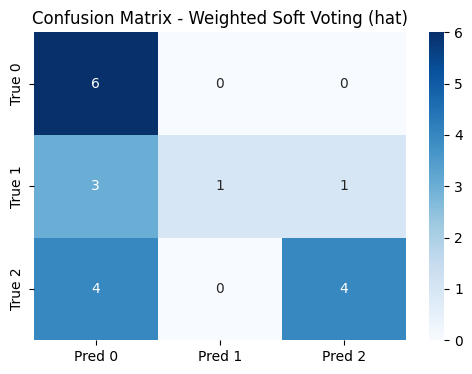

/var/folders/vn/xptkmbp94g59_0vxqhb4_6lc0000gn/T/ipykernel_4356/2352588279.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  soft_preds = df_ws.groupby(group_col, group_keys=False).apply(soft_hat).reset_index(name='final_pred_label')


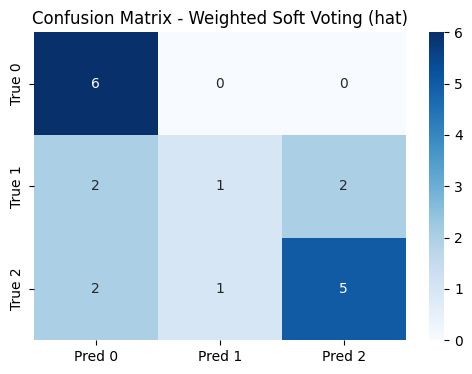

Voting Strategy Summary by Seed


,Seed,Voting Strategy,Accuracy,F1-Score,Precision,Recall
0,1024,Weighted Soft Voting (hat),63.16,59.27,62.18,63.16
1,1234,Weighted Soft Voting (hat),57.89,50.88,45.52,57.89
2,2001,Weighted Soft Voting (hat),68.42,66.92,71.58,68.42
3,2025,Weighted Soft Voting (hat),68.42,66.92,71.58,68.42
4,42,Weighted Soft Voting (hat),57.89,54.63,74.57,57.89


In [ ]:
import pandas as pd
import numpy as np
import re
import ast
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

def convert_to_array(x):
    x = re.sub(r'(?<=\d)\s+(?=\d)', ',', x)
    x = '[' + x + ']'
    array = np.array(ast.literal_eval(x))
    return array 

def all_voting_strategies(df, group_col, pred_col, true_col, softmax_col):

    results_summary = []
    confusion_matrices = {}
    
    def get_metrics(y_true, y_pred):
        return {
            "Accuracy": round(accuracy_score(y_true, y_pred) * 100, 2),
            "F1-Score": round(f1_score(y_true, y_pred, average='weighted') * 100, 2),
            "Precision": round(precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
            "Recall": round(recall_score(y_true, y_pred, average='weighted') * 100, 2)
        }

    def plot_conf_matrix(y_true, y_pred, title):
        labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        df_cm = pd.DataFrame(cm, index=[f'True {l}' for l in labels],
                                  columns=[f'Pred {l}' for l in labels])
        plt.figure(figsize=(6,4))
        sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
        plt.title(title)
        plt.show()
        return df_cm

    # 1. Majority Voting
    majority_voting = df.groupby(group_col)[pred_col].agg(lambda x: x.mode()[0]).reset_index()
    true_labels = df.groupby(group_col)[true_col].first().reset_index()
    results = pd.merge(majority_voting, true_labels, on=group_col)
    y_true, y_pred = results[true_col], results[pred_col]

    # 2. Weighted Soft Voting
    df_ws = df.copy()
    df_ws['weight'] = df_ws[softmax_col].apply(np.max)
    def soft_hat(group):
        probs = np.stack(group[softmax_col].values)
        weights = group['weight'].values.reshape(-1, 1)
        weighted_probs = (probs * weights).sum(axis=0)
        return np.argmax(weighted_probs)
    soft_preds = df_ws.groupby(group_col, group_keys=False).apply(soft_hat).reset_index(name='final_pred_label')
    results = pd.merge(soft_preds, true_labels, on=group_col)
    y_true, y_pred = results[true_col], results['final_pred_label']
    confusion_matrices["Weighted Soft Voting (hat)"] = plot_conf_matrix(y_true, y_pred, "Confusion Matrix - Weighted Soft Voting (hat)")
    results_summary.append(("Weighted Soft Voting (hat)", get_metrics(y_true, y_pred)))

    summary_df = pd.DataFrame({name: metrics for name, metrics in results_summary}).T
    summary_df.index.name = 'Voting Strategy'

    return summary_df, confusion_matrices

base_dir = '/Volumes/Extreme SSD/progetto_tesi/improving_dementia_detection_model/explainability-dementia-alfio/5_seed_ovr_1e7/results'
all_summary_dfs = []

for csv_file in glob.glob(os.path.join(base_dir, 'train_*/test_inferences.csv')):
    seed_folder = os.path.basename(os.path.dirname(csv_file))  # es. 'train_20250720_163655'
    after_seed = seed_folder.split("_seed", 1)[-1]
    test = pd.read_csv(csv_file)
    test['softmax_values'] = test['softmax_values'].apply(lambda x: convert_to_array(x))
    test['softmax_values'] = test['softmax_values'].apply(lambda x: x.squeeze())

    summary_df, _ = all_voting_strategies(test, 'original_rec', 'pred_label', 'true_label', 'softmax_values')
    summary_df['Seed'] = after_seed 
    all_summary_dfs.append(summary_df.reset_index())

final_summary = pd.concat(all_summary_dfs, ignore_index=True)
final_summary = final_summary[['Seed', 'Voting Strategy', 'Accuracy', 'F1-Score', 'Precision', 'Recall']]
final_summary.sort_values(by='Seed', inplace=True, ignore_index=True)

print("Voting Strategy Summary by Seed")
display(final_summary)


In [ ]:
import pandas as pd
import numpy as np
import re
import ast
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from IPython.display import display, HTML

def convert_to_array(x):
    x = re.sub(r'(?<=\d)\s+(?=\d)', ',', x)
    x = '[' + x + ']'
    array = np.array(ast.literal_eval(x))
    return array 

def all_voting_strategies(df, group_col, pred_col, true_col, softmax_col):
    results_summary = []

    def get_metrics(y_true, y_pred):
        return {
            "Accuracy": round(accuracy_score(y_true, y_pred) * 100, 2),
            "F1-Score": round(f1_score(y_true, y_pred, average='weighted') * 100, 2),
            "Precision": round(precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
            "Recall": round(recall_score(y_true, y_pred, average='weighted') * 100, 2)
        }

    # Majority Voting
    majority_voting = df.groupby(group_col)[pred_col].agg(lambda x: x.mode()[0]).reset_index()
    true_labels = df.groupby(group_col)[true_col].first().reset_index()
    results = pd.merge(majority_voting, true_labels, on=group_col)
    y_true, y_pred = results[true_col], results[pred_col]

    # Weighted Soft Voting
    df_ws = df.copy()
    df_ws['weight'] = df_ws[softmax_col].apply(np.max)
    def soft_hat(group):
        probs = np.stack(group[softmax_col].values)
        weights = group['weight'].values.reshape(-1, 1)
        weighted_probs = (probs * weights).sum(axis=0)
        return np.argmax(weighted_probs)
    soft_preds = df_ws.groupby(group_col, group_keys=False).apply(soft_hat).reset_index(name='final_pred_label')
    results = pd.merge(soft_preds, true_labels, on=group_col)
    y_true, y_pred = results[true_col], results['final_pred_label']
    results_summary.append(("Weighted Soft Voting", get_metrics(y_true, y_pred)))

    summary_df = pd.DataFrame({name: metrics for name, metrics in results_summary}).T
    summary_df.index.name = 'Voting Strategy'

    return summary_df

root_dir = '/Volumes/Extreme SSD/progetto_tesi/improving_dementia_detection_model/explainability-dementia-alfio/'

all_summary_dfs = []

pattern = os.path.join(root_dir, '5_seed*/results/train_*/test_inferences.csv')
for csv_file in glob.glob(pattern):
    
    seed_folder = os.path.basename(os.path.dirname(csv_file))  # train_seed_20250730_145500
    match = re.search(r'seed[_]?(.+)', seed_folder)
    after_seed = match.group(1) if match else seed_folder

    strategy_folder = os.path.basename(os.path.abspath(os.path.join(csv_file, "../../../")))

    try:
        test = pd.read_csv(csv_file)
        test['softmax_values'] = test['softmax_values'].apply(lambda x: convert_to_array(x).squeeze())

        summary_df = all_voting_strategies(test, 'original_rec', 'pred_label', 'true_label', 'softmax_values')
        summary_df['Seed'] = after_seed
        summary_df['Strategy'] = strategy_folder
        all_summary_dfs.append(summary_df.reset_index())
    except Exception as e:
        print(f"Errore nel file {csv_file}: {e}")

final_summary = pd.concat(all_summary_dfs, ignore_index=True)
final_summary = final_summary[['Strategy', 'Seed', 'Voting Strategy', 'Accuracy', 'F1-Score', 'Precision', 'Recall']]
final_summary.sort_values(by=['Strategy', 'Seed'], inplace=True, ignore_index=True)

metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
grouped = final_summary.groupby('Strategy')[metrics]
summary_by_strategy = grouped.agg(['mean', 'std']).round(2)
summary_by_strategy.columns = ['_'.join(col).strip() for col in summary_by_strategy.columns]  # flatten multi-index
summary_by_strategy.reset_index(inplace=True)

display(HTML("<h3>Voting Strategy Summary by Seed</h3>"))
display(final_summary)

display(HTML("<h3>Mean and Standard Deviation by Strategy</h3>"))
display(summary_by_strategy)

/var/folders/vn/xptkmbp94g59_0vxqhb4_6lc0000gn/T/ipykernel_4828/3687850527.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  soft_preds = df_ws.groupby(group_col, group_keys=False).apply(soft_hat).reset_index(name='final_pred_label')
/var/folders/vn/xptkmbp94g59_0vxqhb4_6lc0000gn/T/ipykernel_4828/3687850527.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  soft_preds = df_ws.groupby(group_col, group_k

,Strategy,Seed,Voting Strategy,Accuracy,F1-Score,Precision,Recall
0,5_seed,1024,Weighted Soft Voting,52.63,44.00,42.65,52.63
1,5_seed,1234,Weighted Soft Voting,57.89,50.00,45.26,57.89
2,5_seed,2001,Weighted Soft Voting,52.63,45.11,43.86,52.63
3,5_seed,2025,Weighted Soft Voting,68.42,58.01,50.53,68.42
4,5_seed,42,Weighted Soft Voting,57.89,48.61,43.54,57.89
5,5_seed_CV,1024,Weighted Soft Voting,47.37,37.99,35.63,47.37
6,5_seed_CV,1234,Weighted Soft Voting,63.16,53.41,47.02,63.16
7,5_seed_CV,2001,Weighted Soft Voting,52.63,44.75,41.29,52.63
8,5_seed_CV,2025,Weighted Soft Voting,57.89,49.12,42.81,57.89
9,5_seed_CV,42,Weighted Soft Voting,57.89,56.03,72.47,57.89


,Strategy,Accuracy_mean,Accuracy_std,F1-Score_mean,F1-Score_std,Precision_mean,Precision_std,Recall_mean,Recall_std
0,5_seed,57.89,6.45,49.15,5.53,45.17,3.14,57.89,6.45
1,5_seed_CV,55.79,6.00,48.26,7.17,47.84,14.36,55.79,6.00
2,5_seed_ovr,66.31,6.00,63.27,6.03,71.88,6.31,66.31,6.00
3,5_seed_ovr_1e7,63.16,5.27,59.72,7.21,65.09,11.89,63.16,5.27
4,5_seed_ovr_CV,48.42,5.76,40.37,5.41,36.50,4.41,48.42,5.76
5,5_seed_ovr_CV_1e_7,51.58,4.40,43.30,4.33,38.77,3.38,51.58,4.40


# Weight soft voting (hybrid)

In [ ]:
import pandas as pd
import numpy as np
import re
import ast
import os
import glob
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# ---------- Utility ----------
def convert_to_array(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        arr = np.array(x)
        return arr.squeeze()
    if isinstance(x, str):
        s = x.strip()
        # If the square bracket is missing, I add it and convert spaces into commas.
        if not (s.startswith('[') and s.endswith(']')):
            s = re.sub(r'(?<=\d)\s+(?=\d)', ',', s)
            s = '[' + s + ']'
        arr = np.array(ast.literal_eval(s))
        return arr.squeeze()
    # fallback
    return np.array(x).squeeze()

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": round(accuracy_score(y_true, y_pred) * 100, 2),
        "F1-Score": round(f1_score(y_true, y_pred, average='weighted') * 100, 2),
        "Precision": round(precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
        "Recall": round(recall_score(y_true, y_pred, average='weighted') * 100, 2),
    }

def monitor_voting(df, group_col, pred_col, true_col, softmax_col, softmax_monitor_col, alpha=0.3):
    results_summary = []
    confusion_matrices = {}

    # Majority
    majority_voting = df.groupby(group_col)[pred_col].agg(lambda x: x.mode()[0]).reset_index()
    true_labels = df.groupby(group_col)[true_col].first().reset_index()
    res_major = pd.merge(majority_voting, true_labels, on=group_col, how='inner')
    y_true_mj, y_pred_mj = res_major[true_col].to_numpy(), res_major[pred_col].to_numpy()

    # Weighted Soft Voting
    df_ws = df.copy()
    df_ws[softmax_col] = df_ws[softmax_col].apply(convert_to_array)
    df_ws[softmax_monitor_col] = df_ws[softmax_monitor_col].apply(convert_to_array)
    df_ws['weight'] = alpha * df_ws[softmax_monitor_col].apply(np.max) + (1 - alpha) * df_ws[softmax_col].apply(np.max)

    def soft_hat(group):
        probs = np.stack(group[softmax_col].values)           # (n_crops, n_classes)
        weights = group['weight'].values.reshape(-1, 1)       # (n_crops, 1)
        weighted_probs = (probs * weights).sum(axis=0)        # (n_classes,)
        return int(np.argmax(weighted_probs))

    soft_preds = df_ws.groupby(group_col, group_keys=False).apply(soft_hat).reset_index(name='final_pred_label')
    res_soft = pd.merge(soft_preds, true_labels, on=group_col, how='inner')
    y_true_sh, y_pred_sh = res_soft[true_col].to_numpy(), res_soft['final_pred_label'].to_numpy()
    confusion_matrices["Weighted Soft Voting (monitor hat)"] = confusion_matrix(y_true_sh, y_pred_sh)
    results_summary.append(("Weighted Soft Voting (monitor hat)", get_metrics(y_true_sh, y_pred_sh)))

    summary_df = pd.DataFrame({name: metrics for name, metrics in results_summary}).T
    summary_df.index.name = 'Voting Strategy'
    return summary_df, confusion_matrices

base_dir_model   = '/Volumes/Extreme SSD/progetto_tesi/improving_dementia_detection_model/explainability-dementia-alfio/5_seed/results'
base_dir_monitor = '/Volumes/Extreme SSD/progetto_tesi/improving_dementia_detection_model/explainability-dementia-alfio/5_seed/monitor'

alpha = 0.3  # change calibration here

all_summary_dfs = []
missing_monitor = []

for csv_file in glob.glob(os.path.join(base_dir_model, 'train_*/test_inferences.csv')):
    seed_folder = os.path.basename(os.path.dirname(csv_file))  # es. 'train_20250719_141127_seed1234'
    after_seed = seed_folder.split("_seed", 1)[-1]
    monitor_csv = os.path.join(base_dir_monitor, seed_folder, 'detailed_inference_test.csv')

    if not os.path.exists(monitor_csv):
        missing_monitor.append(seed_folder)
        continue

    test_df = pd.read_csv(csv_file)
    if 'softmax_values' in test_df.columns:
        test_df['softmax_values'] = test_df['softmax_values'].apply(convert_to_array)
    else:
        raise KeyError(f"'softmax_values' not found in {csv_file}")

    mon_df = pd.read_csv(monitor_csv)
    if 'logits' in mon_df.columns:
        mon_df = mon_df.drop(columns=['logits'])
    mon_df = mon_df.rename(columns={
        'softmax': 'softmax_monitor',
        'pred_label': 'pred_monitor',
        'true_label': 'true_monitor'
    })
    if 'softmax_monitor' not in mon_df.columns:
        if 'softmax_values' in mon_df.columns:
            mon_df = mon_df.rename(columns={'softmax_values': 'softmax_monitor'})
        else:
            raise KeyError(f"'softmax_monitor' not found in {monitor_csv}")

    mon_df['softmax_monitor'] = mon_df['softmax_monitor'].apply(convert_to_array)

    # --- Merge per crop ---
    if 'crop_file' not in test_df.columns or 'crop_file' not in mon_df.columns:
        raise KeyError("You need the ‘crop_file’ column in both CSV files to perform the merge.")

    merged = test_df.merge(mon_df[['crop_file', 'softmax_monitor', 'pred_monitor', 'true_monitor']],
                           on='crop_file', how='inner')
    
    summary_df, _ = monitor_voting(
        merged,
        group_col='original_rec',
        pred_col='pred_label',
        true_col='true_label',
        softmax_col='softmax_values',
        softmax_monitor_col='softmax_monitor',
        alpha=alpha
    )

    summary_df['Seed'] = after_seed
    summary_df['Alpha'] = alpha
    all_summary_dfs.append(summary_df.reset_index())

if not all_summary_dfs:
    raise RuntimeError("No summary created. Check the paths and the presence of the files.")

final_summary = pd.concat(all_summary_dfs, ignore_index=True)
final_summary = final_summary[['Seed', 'Alpha', 'Voting Strategy', 'Accuracy', 'F1-Score', 'Precision', 'Recall']]
final_summary.sort_values(by=['Voting Strategy','Seed'], inplace=True, ignore_index=True)

print("Voting Strategy Summary by Seed (con monitor hat)")
display(final_summary)

if missing_monitor:
    print("\n[Warning] Monitor files not found for the following seeds:")
    for sf in missing_monitor:
        print(" -", sf)


/var/folders/vn/xptkmbp94g59_0vxqhb4_6lc0000gn/T/ipykernel_8882/3653626281.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  soft_preds = df_ws.groupby(group_col, group_keys=False).apply(soft_hat).reset_index(name='final_pred_label')
/var/folders/vn/xptkmbp94g59_0vxqhb4_6lc0000gn/T/ipykernel_8882/3653626281.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  soft_preds = df_ws.groupby(group_col, group_k

Voting Strategy Summary by Seed (con monitor hat)


/var/folders/vn/xptkmbp94g59_0vxqhb4_6lc0000gn/T/ipykernel_8882/3653626281.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  soft_preds = df_ws.groupby(group_col, group_keys=False).apply(soft_hat).reset_index(name='final_pred_label')


,Seed,Alpha,Voting Strategy,Accuracy,F1-Score,Precision,Recall
0,1024,0.3,Weighted Soft Voting (monitor hat),52.63,44.00,42.65,52.63
1,1234,0.3,Weighted Soft Voting (monitor hat),57.89,50.00,45.26,57.89
2,2001,0.3,Weighted Soft Voting (monitor hat),57.89,50.36,47.30,57.89
3,2025,0.3,Weighted Soft Voting (monitor hat),68.42,58.01,50.53,68.42
4,42,0.3,Weighted Soft Voting (monitor hat),57.89,48.61,43.54,57.89
